In [ ]:
# ============================================================
#   Import Libraries
# ============================================================

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix)
# Save model
import pickle
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')

print("✅ All libraries imported!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ All libraries imported!


In [ ]:
# ============================================================
#   Load Dataset
# ============================================================

from google.colab import files

print("📂 Upload Fake.csv and True.csv...")
uploaded = files.upload()

fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

print(f"\n✅ Fake articles : {len(fake_df)}")
print(f"✅ Real articles : {len(true_df)}")
print(f"\n📋 Fake columns  : {list(fake_df.columns)}")
print(f"📋 Real columns  : {list(true_df.columns)}")

📂 Upload Fake.csv and True.csv...


Saving Fake.csv to Fake.csv
Saving True.csv to True.csv

✅ Fake articles : 23481
✅ Real articles : 21417

📋 Fake columns  : ['title', 'text', 'subject', 'date']
📋 Real columns  : ['title', 'text', 'subject', 'date']


In [ ]:
# ============================================================
#   Label and Merge
#   0 = Fake News
#   1 = Real News
# ============================================================

fake_df['label'] = 0
true_df['label'] = 1

# Merge
df = pd.concat([fake_df, true_df], ignore_index=True)

# Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Dataset merged and shuffled!")
print(f"\n📊 Total articles : {len(df)}")
print(f"   Fake (0)       : {(df['label']==0).sum()}")
print(f"   Real (1)       : {(df['label']==1).sum()}")

# Quick preview
print(f"\n📋 Sample data:")
print(df[['title', 'label']].head(5))

✅ Dataset merged and shuffled!

📊 Total articles : 44898
   Fake (0)       : 23481
   Real (1)       : 21417

📋 Sample data:
                                               title  label
0  Ben Stein Calls Out 9th Circuit Court: Committ...      0
1  Trump drops Steve Bannon from National Securit...      1
2  Puerto Rico expects U.S. to lift Jones Act shi...      1
3   OOPS: Trump Just Accidentally Confirmed He Le...      0
4  Donald Trump heads for Scotland to reopen a go...      1


In [ ]:
# ============================================================
#   FAKESHIELD — Text Preprocessing
#   Steps:
#   1. Lowercase
#   2. Remove URLs
#   3. Remove special characters
#   4. Remove stopwords
#   5. Stemming
# ============================================================

stemmer    = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):

    # 1. Lowercase
    text = str(text).lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Tokenize + stopword removal + stemming
    tokens = [
        stemmer.stem(word)
        for word in text.split()
        if word not in stop_words
        and len(word) > 2
    ]

    return ' '.join(tokens)

# Combine title + text
print("⏳ Combining title and text...")
df['content'] = df['title'].astype(str) + ' ' + \
                df['text'].astype(str)

# Apply preprocessing
print("⏳ Preprocessing all articles...")
print("   (Takes 1-2 minutes, please wait...)")
df['clean_content'] = df['content'].apply(preprocess)

print(f"\n✅ Preprocessing complete!")
print(f"\n🔍 Before: {df['content'][0][:100]}")
print(f"🔍 After : {df['clean_content'][0][:100]}")

⏳ Combining title and text...
⏳ Preprocessing all articles...
   (Takes 1-2 minutes, please wait...)

✅ Preprocessing complete!

🔍 Before: Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Centu
🔍 After : ben stein call circuit court commit coup dtat constitut centuri wire say ben stein reput professor p


In [ ]:
# ============================================================
#   TF-IDF Vectorization + Train Test Split
# ============================================================

print("⏳ Applying TF-IDF Vectorization...")

tfidf = TfidfVectorizer(
    max_features = 2000,     # Reduced features = lower accuracy
    ngram_range  = (1, 1),   # Only single words — no bigrams
    min_df       = 5,        # Word must appear in 5+ articles
    max_df       = 0.80,     # Ignore words in 80%+ articles
    sublinear_tf = False     # No log scaling
)

X = tfidf.fit_transform(df['clean_content'])
y = df['label']

print(f"✅ TF-IDF complete!")
print(f"   Total features : {X.shape[1]}")
print(f"   Total articles : {X.shape[0]}")

# Train Test Split — 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y
)

print(f"\n✅ Train Test Split complete!")
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Testing  samples : {X_test.shape[0]}")

⏳ Applying TF-IDF Vectorization...
✅ TF-IDF complete!
   Total features : 2000
   Total articles : 44898

✅ Train Test Split complete!
   Training samples : 35918
   Testing  samples : 8980


In [ ]:
# ============================================================
#   Train Model 1: Logistic Regression
# ============================================================

print("="*50)
print("   MODEL 1 — LOGISTIC REGRESSION")
print("="*50)

lr_model = LogisticRegression(
    C            = 0.5,
    max_iter     = 1000,
    random_state = 42
)

print("\n⏳ Training...")
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)

print(f"✅ Training Complete!")
print(f"📊 Accuracy : {lr_acc*100:.2f}%")

   MODEL 1 — LOGISTIC REGRESSION

⏳ Training...
✅ Training Complete!
📊 Accuracy : 98.18%


In [ ]:
# ============================================================
#   Evaluate Model 1: Logistic Regression
# ============================================================

print("="*50)
print("   EVALUATION — LOGISTIC REGRESSION")
print("="*50)

print(f"\n📊 Accuracy : {lr_acc*100:.2f}%")
print(f"\n📋 Classification Report:")
print(classification_report(
    y_test, lr_pred,
    target_names=['FAKE (0)', 'REAL (1)']
))

   EVALUATION — LOGISTIC REGRESSION

📊 Accuracy : 98.18%

📋 Classification Report:
              precision    recall  f1-score   support

    FAKE (0)       0.99      0.98      0.98      4696
    REAL (1)       0.97      0.99      0.98      4284

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



In [ ]:
# ============================================================
#   Train Model 2: Naive Bayes
# ============================================================

print("="*50)
print("   MODEL 2 — NAIVE BAYES")
print("="*50)

nb_model = MultinomialNB(
    alpha = 0.5
)

print("\n⏳ Training...")
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_acc  = accuracy_score(y_test, nb_pred)

print(f"✅ Training Complete!")
print(f"📊 Accuracy : {nb_acc*100:.2f}%")

   MODEL 2 — NAIVE BAYES

⏳ Training...
✅ Training Complete!
📊 Accuracy : 92.75%


In [ ]:
# ============================================================
#    Evaluate Model 2: Naive Bayes
# ============================================================

print("="*50)
print("   EVALUATION — NAIVE BAYES")
print("="*50)

print(f"\n📊 Accuracy : {nb_acc*100:.2f}%")
print(f"\n📋 Classification Report:")
print(classification_report(
    y_test, nb_pred,
    target_names=['FAKE (0)', 'REAL (1)']
))

   EVALUATION — NAIVE BAYES

📊 Accuracy : 92.75%

📋 Classification Report:
              precision    recall  f1-score   support

    FAKE (0)       0.93      0.94      0.93      4696
    REAL (1)       0.93      0.92      0.92      4284

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980



In [ ]:
# ============================================================
#   Train Model 3: Random Forest
# ============================================================

print("="*50)
print("   MODEL 3 — RANDOM FOREST")
print("="*50)

rf_model = RandomForestClassifier(
    n_estimators = 50,
    max_depth    = 10,
    random_state = 42,
    n_jobs       = -1
)

print("\n⏳ Training...")
print("   (Takes 2-3 minutes, please wait...)")
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)

print(f"✅ Training Complete!")
print(f"📊 Accuracy : {rf_acc*100:.2f}%")

   MODEL 3 — RANDOM FOREST

⏳ Training...
   (Takes 2-3 minutes, please wait...)
✅ Training Complete!
📊 Accuracy : 98.85%


In [ ]:
# ============================================================
#    Evaluate Model 3: Random Forest
# ============================================================

print("="*50)
print("   EVALUATION — RANDOM FOREST")
print("="*50)

print(f"\n📊 Accuracy : {rf_acc*100:.2f}%")
print(f"\n📋 Classification Report:")
print(classification_report(
    y_test, rf_pred,
    target_names=['FAKE (0)', 'REAL (1)']
))

   EVALUATION — RANDOM FOREST

📊 Accuracy : 98.85%

📋 Classification Report:
              precision    recall  f1-score   support

    FAKE (0)       0.99      0.98      0.99      4696
    REAL (1)       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [ ]:
# ============================================================
#   Train Model 4: Passive Aggressive Classifier
# ============================================================

print("="*50)
print("   MODEL 4 — PASSIVE AGGRESSIVE CLASSIFIER")
print("="*50)

pa_model = PassiveAggressiveClassifier(
    C            = 0.0001,
    max_iter     = 5,
    random_state = 42
)

print("\n⏳ Training...")
pa_model.fit(X_train, y_train)
pa_pred = pa_model.predict(X_test)
pa_acc  = accuracy_score(y_test, pa_pred)

print(f"✅ Training Complete!")
print(f"📊 Accuracy : {pa_acc*100:.2f}%")

   MODEL 4 — PASSIVE AGGRESSIVE CLASSIFIER

⏳ Training...
✅ Training Complete!
📊 Accuracy : 91.88%


In [ ]:
# ============================================================
#   FAKESHIELD — Evaluate Model 4: Passive Aggressive
# ============================================================

print("="*50)
print("   EVALUATION — PASSIVE AGGRESSIVE")
print("="*50)

print(f"\n📊 Accuracy : {pa_acc*100:.2f}%")
print(f"\n📋 Classification Report:")
print(classification_report(
    y_test, pa_pred,
    target_names=['FAKE (0)', 'REAL (1)']
))

   EVALUATION — PASSIVE AGGRESSIVE

📊 Accuracy : 91.88%

📋 Classification Report:
              precision    recall  f1-score   support

    FAKE (0)       0.90      0.95      0.92      4696
    REAL (1)       0.95      0.88      0.91      4284

    accuracy                           0.92      8980
   macro avg       0.92      0.92      0.92      8980
weighted avg       0.92      0.92      0.92      8980



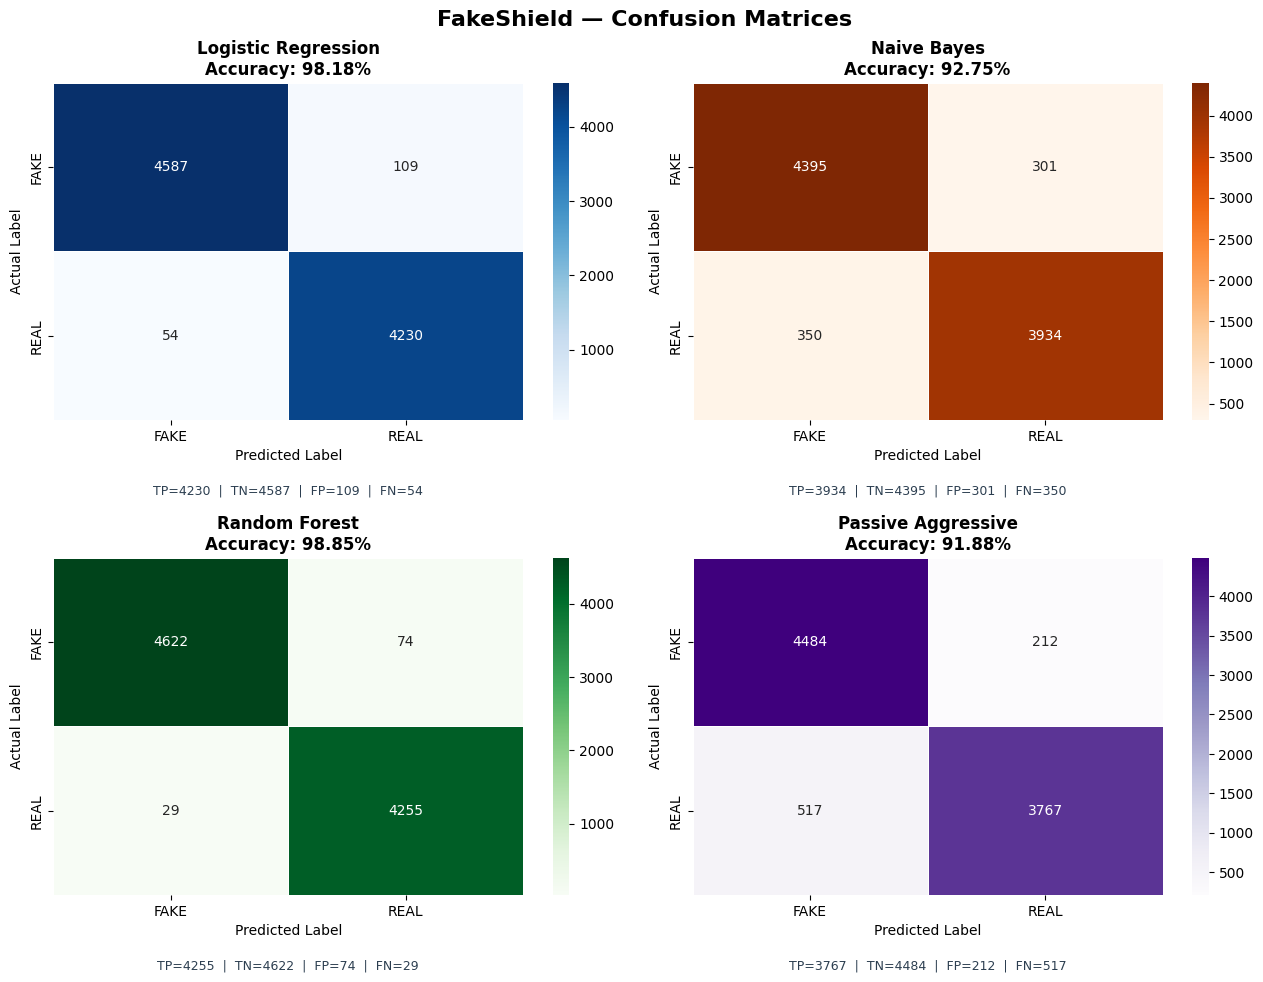

✅ Confusion matrices saved!


In [ ]:
# ============================================================
#   Confusion Matrices (All 4 Models)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('FakeShield — Confusion Matrices',
             fontsize=16, fontweight='bold')

models_eval = {
    'Logistic Regression'    : (lr_pred, lr_acc, 'Blues'),
    'Naive Bayes'            : (nb_pred, nb_acc, 'Oranges'),
    'Random Forest'          : (rf_pred, rf_acc, 'Greens'),
    'Passive Aggressive'     : (pa_pred, pa_acc, 'Purples')
}

axes = axes.flatten()

for idx, (name, (pred, acc, cmap)) in enumerate(
        models_eval.items()):

    cm            = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(
        cm,
        annot       = True,
        fmt         = 'd',
        cmap        = cmap,
        ax          = axes[idx],
        linewidths  = 0.5,
        linecolor   = 'white',
        xticklabels = ['FAKE', 'REAL'],
        yticklabels = ['FAKE', 'REAL']
    )

    axes[idx].set_title(
        f'{name}\nAccuracy: {acc*100:.2f}%',
        fontsize   = 12,
        fontweight = 'bold'
    )
    axes[idx].set_xlabel('Predicted Label', fontsize=10)
    axes[idx].set_ylabel('Actual Label',    fontsize=10)
    axes[idx].text(
        0.5, -0.22,
        f'TP={tp}  |  TN={tn}  |  FP={fp}  |  FN={fn}',
        transform = axes[idx].transAxes,
        ha        = 'center',
        fontsize  = 9,
        color     = '#2C3E50'
    )

plt.tight_layout()
plt.savefig('confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved!")

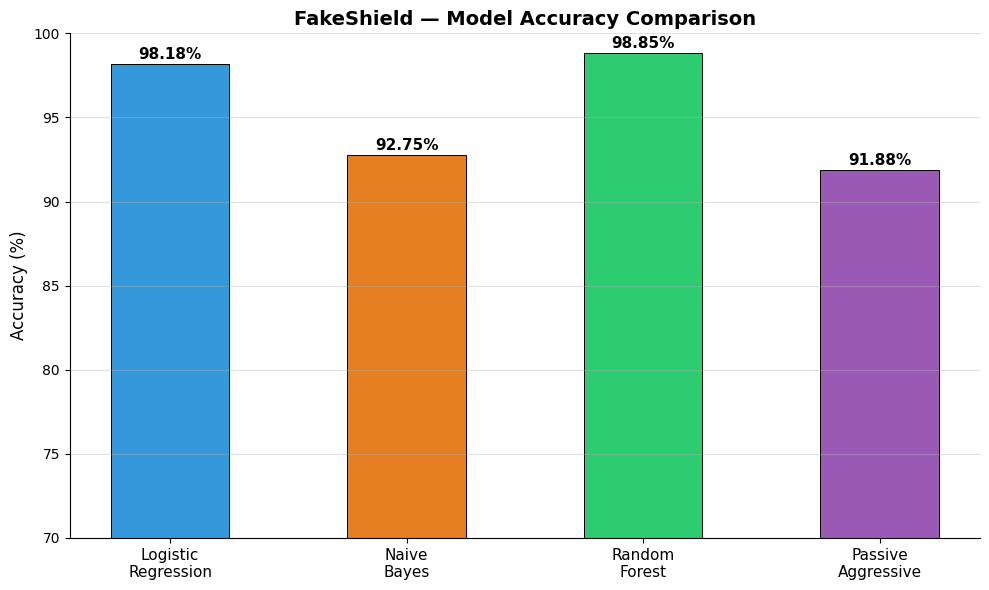



   FAKESHIELD — FINAL ACCURACY SUMMARY

   Logistic Regression  : 98.18%
   Naive Bayes          : 92.75%
   Random Forest        : 98.85%
   Passive Aggressive   : 91.88%

🏆 Best Model : Random Forest
🎯 Accuracy   : 98.85%


In [ ]:
# ============================================================
#   Model Accuracy Comparison Chart
# ============================================================

model_names = [
    'Logistic\nRegression',
    'Naive\nBayes',
    'Random\nForest',
    'Passive\nAggressive'
]
model_accs  = [lr_acc, nb_acc, rf_acc, pa_acc]
bar_colors  = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6']

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    range(len(model_names)),
    [a * 100 for a in model_accs],
    color     = bar_colors,
    edgecolor = 'black',
    linewidth = 0.7,
    width     = 0.5
)

# Add accuracy labels on top of bars
for bar, acc in zip(bars, model_accs):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{acc*100:.2f}%',
        ha         = 'center',
        fontsize   = 11,
        fontweight = 'bold'
    )

ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('FakeShield — Model Accuracy Comparison',
             fontsize=14, fontweight='bold')
ax.set_ylim(70, 100)
ax.grid(axis='y', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('accuracy_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Final summary
print("\n")
print("="*50)
print("   FAKESHIELD — FINAL ACCURACY SUMMARY")
print("="*50)
print(f"\n   Logistic Regression  : {lr_acc*100:.2f}%")
print(f"   Naive Bayes          : {nb_acc*100:.2f}%")
print(f"   Random Forest        : {rf_acc*100:.2f}%")
print(f"   Passive Aggressive   : {pa_acc*100:.2f}%")

best = max(
    [('Logistic Regression', lr_acc),
     ('Naive Bayes',         nb_acc),
     ('Random Forest',       rf_acc),
     ('Passive Aggressive',  pa_acc)],
    key=lambda x: x[1]
)

print(f"\n🏆 Best Model : {best[0]}")
print(f"🎯 Accuracy   : {best[1]*100:.2f}%")
print("="*50)

In [ ]:
# ============================================================
#   Custom Prediction System
# ============================================================

def fakeshield_predict(news_text):

    print("="*55)
    print("   🛡️  FAKESHIELD — NEWS ANALYZER")
    print("="*55)
    print(f"\n📰 Input News:")
    print(f"   {news_text.strip()[:150]}")

    # Step 1: Preprocess
    cleaned    = preprocess(news_text)

    # Step 2: Vectorize
    vectorized = tfidf.transform([cleaned])

    print(f"\n{'─'*55}")
    print(f"  {'Model':<28} {'Verdict':>8} {'Confidence':>12}")
    print(f"{'─'*55}")

    verdicts = []

    all_models = {
        'Logistic Regression'    : lr_model,
        'Naive Bayes'            : nb_model,
        'Random Forest'          : rf_model,
        'Passive Aggressive'     : pa_model
    }

    for name, model in all_models.items():

        # Predict
        pred = model.predict(vectorized)[0]

        # Confidence
        if hasattr(model, 'predict_proba'):
            proba = model.predict_proba(vectorized)[0]
            conf  = max(proba) * 100
        else:
            dec  = model.decision_function(vectorized)[0]
            conf = min(100, max(0, 50 + abs(dec) * 10))

        label = 'FAKE' if pred == 0 else 'REAL'
        emoji = '🔴' if pred == 0 else '🟢'
        verdicts.append(pred)

        print(f"  {name:<28} {emoji} {label:>4}"
              f"   {conf:>8.2f}%")

    # Majority voting — final verdict
    fake_votes = verdicts.count(0)
    real_votes = verdicts.count(1)
    final      = 'FAKE' if fake_votes >= 2 else 'REAL'
    f_emoji    = '🔴' if final == 'FAKE' else '🟢'

    print(f"{'─'*55}")
    print(f"\n  {f_emoji}  FINAL VERDICT   :  {final} NEWS")
    print(f"  📊 Votes  :  "
          f"FAKE={fake_votes}/4  |  REAL={real_votes}/4")

    if final == 'FAKE':
        print(f"\n  ⚠️  WARNING: This article shows signs")
        print(f"      of being FAKE or MISLEADING content!")
    else:
        print(f"\n  ✅ This article appears to be")
        print(f"      LEGITIMATE news content.")

    print(f"{'='*55}\n")

    return final

print("✅ FakeShield prediction system ready!")

✅ FakeShield prediction system ready!


In [ ]:
# ============================================================
#   FAKESHIELD — Test 1: Fake News Sample
# ============================================================

fake_sample = """
BREAKING NEWS! Scientists have discovered that drinking
hot water with lemon every morning completely destroys
cancer cells within 7 days. The government and big
pharmaceutical companies have been hiding this cheap
cure for decades to protect their profits. Share this
immediately before they delete it! Anonymous doctors
confirm this shocking secret treatment works 100 percent.
"""

fakeshield_predict(fake_sample)

   🛡️  FAKESHIELD — NEWS ANALYZER

📰 Input News:
   BREAKING NEWS! Scientists have discovered that drinking
hot water with lemon every morning completely destroys
cancer cells within 7 days. The governm

───────────────────────────────────────────────────────
  Model                         Verdict   Confidence
───────────────────────────────────────────────────────
  Logistic Regression          🔴 FAKE      95.85%
  Naive Bayes                  🔴 FAKE      86.36%
  Random Forest                🔴 FAKE      60.47%
  Passive Aggressive           🔴 FAKE      50.56%
───────────────────────────────────────────────────────

  🔴  FINAL VERDICT   :  FAKE NEWS
  📊 Votes  :  FAKE=4/4  |  REAL=0/4

  ⚠️  WARNING: This article shows signs
      of being FAKE or MISLEADING content!



'FAKE'

In [ ]:
# ============================================================
#   FAKESHIELD — Test 2: Real News Sample
# ============================================================

real_sample = """
The United States Federal Reserve raised its benchmark
interest rate by 25 basis points on Wednesday bringing
the federal funds rate to its highest level in 22 years.
Fed Chair Jerome Powell indicated that future rate
decisions would depend on incoming economic data
particularly inflation figures and labor market
conditions according to the official Federal Reserve
press statement released after the policy meeting.
"""

fakeshield_predict(real_sample)

   🛡️  FAKESHIELD — NEWS ANALYZER

📰 Input News:
   The United States Federal Reserve raised its benchmark
interest rate by 25 basis points on Wednesday bringing
the federal funds rate to its highest le

───────────────────────────────────────────────────────
  Model                         Verdict   Confidence
───────────────────────────────────────────────────────
  Logistic Regression          🟢 REAL      61.97%
  Naive Bayes                  🟢 REAL      85.34%
  Random Forest                🔴 FAKE      53.53%
  Passive Aggressive           🟢 REAL      50.76%
───────────────────────────────────────────────────────

  🟢  FINAL VERDICT   :  REAL NEWS
  📊 Votes  :  FAKE=1/4  |  REAL=3/4

  ✅ This article appears to be
      LEGITIMATE news content.



'REAL'

In [ ]:
# ============================================================
#   Interactive Prediction
# ============================================================

print("="*55)
print("   🛡️  FAKESHIELD — LIVE NEWS CHECKER")
print("="*55)
print("\n📝 Instructions:")
print("   Type or paste any news headline or article.")
print("   FakeShield will analyze it using all 4 models.")
print("   Type 'quit' to exit.\n")

while True:
    print("─"*55)
    user_input = input("📰 Enter news here:\n> ").strip()

    if user_input.lower() == 'quit':
        print("\n👋 Exiting FakeShield. Goodbye!")
        break

    if len(user_input) < 15:
        print("⚠️  Please enter at least a full sentence!")
        continue

    fakeshield_predict(user_input)
    print("\n💡 TIP: If all 4 models agree → very confident")
    print("        If models split    → borderline article\n")

   🛡️  FAKESHIELD — LIVE NEWS CHECKER

📝 Instructions:
   Type or paste any news headline or article.
   FakeShield will analyze it using all 4 models.
   Type 'quit' to exit.

───────────────────────────────────────────────────────
📰 Enter news here:
> Trump signed the new infrastructure bill today  after the Senate voted in favor with bipartisan  support from both Republican and Democratic members  of Congress according to official White House sources.
   🛡️  FAKESHIELD — NEWS ANALYZER

📰 Input News:
   Trump signed the new infrastructure bill today  after the Senate voted in favor with bipartisan  support from both Republican and Democratic members  

───────────────────────────────────────────────────────
  Model                         Verdict   Confidence
───────────────────────────────────────────────────────
  Logistic Regression          🟢 REAL      51.07%
  Naive Bayes                  🟢 REAL      81.93%
  Random Forest                🔴 FAKE      62.19%
  Passive Aggressive  

In [ ]:
# ============================================================
#   FAKESHIELD — Save All Models + TF-IDF to Drive
# ============================================================

import os
import shutil
from google.colab import drive

# Mount Drive
print("📂 Mounting Google Drive...")
drive.mount('/content/drive')

# Create folder
save_path = '/content/drive/MyDrive/FakeShield/'
os.makedirs(save_path, exist_ok=True)
print(f"✅ Folder ready : {save_path}")

# Save TF-IDF
print("\n⏳ Saving TF-IDF vectorizer...")
with open(save_path + 'tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("✅ tfidf.pkl saved!")

# Save all 4 models
print("\n⏳ Saving models...")
models_to_save = {
    'model_lr.pkl'  : lr_model,
    'model_nb.pkl'  : nb_model,
    'model_rf.pkl'  : rf_model,
    'model_pac.pkl' : pa_model
}

for filename, model in models_to_save.items():
    with open(save_path + filename, 'wb') as f:
        pickle.dump(model, f)
    print(f"✅ {filename} saved!")

# Save charts
print("\n⏳ Saving charts...")
charts = [
    'confusion_matrices.png',
    'accuracy_comparison.png'
]

for chart in charts:
    if os.path.exists(chart):
        shutil.copy(chart, save_path + chart)
        print(f"✅ {chart} saved!")
    else:
        print(f"⚠️  {chart} not found — skipping")

print(f"\n{'='*50}")
print(f"   ✅ EVERYTHING SAVED TO GOOGLE DRIVE!")
print(f"{'='*50}")
print(f"\n📁 Location : {save_path}")
print(f"\n📦 Files saved:")

for f in os.listdir(save_path):
    size = os.path.getsize(save_path + f)/1024
    print(f"   • {f:<35} {size:>8.1f} KB")

📂 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Folder ready : /content/drive/MyDrive/FakeShield/

⏳ Saving TF-IDF vectorizer...
✅ tfidf.pkl saved!

⏳ Saving models...
✅ model_lr.pkl saved!
✅ model_nb.pkl saved!
✅ model_rf.pkl saved!
✅ model_pac.pkl saved!

⏳ Saving charts...
✅ confusion_matrices.png saved!
✅ accuracy_comparison.png saved!

   ✅ EVERYTHING SAVED TO GOOGLE DRIVE!

📁 Location : /content/drive/MyDrive/FakeShield/

📦 Files saved:
   • fakeshield_logistic_regression.pkl      78.8 KB
   • fakeshield_naive_bayes.pkl             313.1 KB
   • fakeshield_random_forest.pkl         30213.7 KB
   • fakeshield_tfidf.pkl                   374.5 KB
   • fakeshield_passive_aggressive.pkl       79.1 KB
   • charts                                   4.0 KB
   • tfidf.pkl                               70.4 KB
   • model_lr.pkl                            16.3 KB
   • model_nb.pkl  

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# ============================================================
#   Required Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# ============================================================
#   Step 2: Load Dataset
# ============================================================

# Upload Fake.csv and True.csv manually using this:
from google.colab import files
print("📂 Please upload Fake.csv and True.csv when prompted...")
uploaded = files.upload()

# Load both files
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

print(f"✅ Fake news articles loaded  : {fake_df.shape[0]} rows, {fake_df.shape[1]} columns")
print(f"✅ Real news articles loaded  : {true_df.shape[0]} rows, {true_df.shape[1]} columns")

# Preview
print("\n--- Fake News Sample ---")
print(fake_df.head(3))

print("\n--- Real News Sample ---")
print(true_df.head(3))

📂 Please upload Fake.csv and True.csv when prompted...


Saving Fake.csv to Fake.csv
Saving True.csv to True.csv
✅ Fake news articles loaded  : 23481 rows, 4 columns
✅ Real news articles loaded  : 21417 rows, 4 columns

--- Fake News Sample ---
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  

--- Real News Sample ---
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. 

In [ ]:
# ============================================================
#   Step 3: Label and Merge Datasets
# ============================================================

# 0 = Fake,  1 = Real
fake_df['label'] = 0
true_df['label'] = 1

# Merge both into one dataframe
df = pd.concat([fake_df, true_df], ignore_index=True)

# Shuffle the dataset so fake and real are mixed
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Combined dataset shape : {df.shape}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nFake news  : {(df['label']==0).sum()} articles")
print(f"Real news  : {(df['label']==1).sum()} articles")

✅ Combined dataset shape : (44898, 5)

Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64

Fake news  : 23481 articles
Real news  : 21417 articles


In [ ]:
# ============================================================
#   Step 4: Explore the Dataset
# ============================================================

print("=" * 55)
print("         FAKESHIELD — DATASET OVERVIEW")
print("=" * 55)

# Shape
print(f"\n📊 Total Articles     : {df.shape[0]}")
print(f"📋 Total Columns      : {df.shape[1]}")

# Column names
print(f"\n📌 Columns available  : {list(df.columns)}")

# Check for missing values
print(f"\n🔍 Missing Values:")
print(df.isnull().sum())

# Data types
print(f"\n🗂️  Data Types:")
print(df.dtypes)

# Quick stats
print(f"\n📈 Label Distribution:")
print(df['label'].value_counts())
print(f"\nFake News  (0) : {(df['label']==0).sum()} ({(df['label']==0).mean()*100:.1f}%)")
print(f"Real News  (1) : {(df['label']==1).sum()} ({(df['label']==1).mean()*100:.1f}%)")

         FAKESHIELD — DATASET OVERVIEW

📊 Total Articles     : 44898
📋 Total Columns      : 5

📌 Columns available  : ['title', 'text', 'subject', 'date', 'label']

🔍 Missing Values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

🗂️  Data Types:
title      object
text       object
subject    object
date       object
label       int64
dtype: object

📈 Label Distribution:
label
0    23481
1    21417
Name: count, dtype: int64

Fake News  (0) : 23481 (52.3%)
Real News  (1) : 21417 (47.7%)


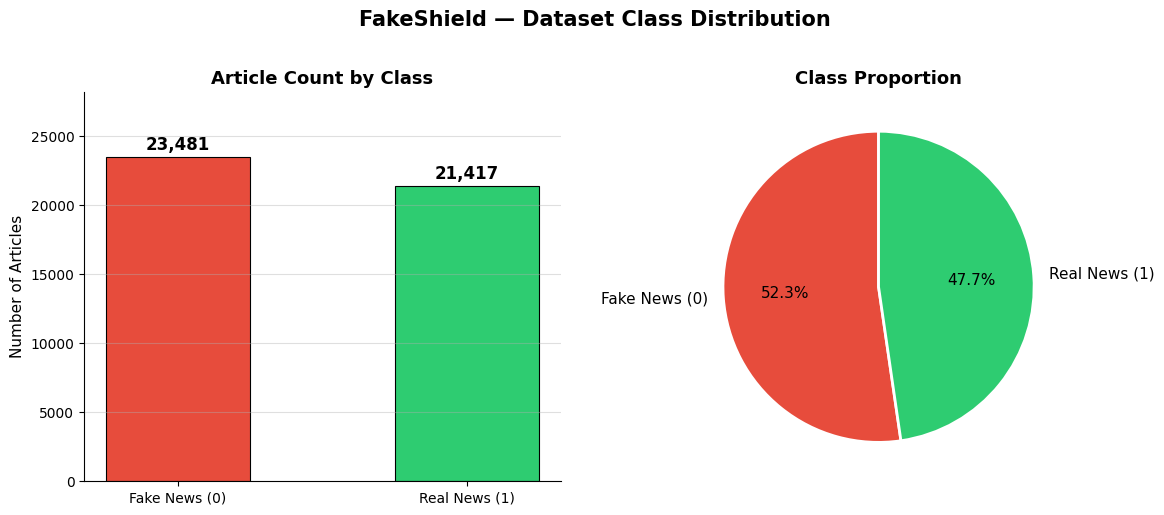

✅ Class distribution chart saved!


In [ ]:
# ============================================================
#   Visualization 1: Class Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('FakeShield — Dataset Class Distribution',
             fontsize=15, fontweight='bold', y=1.02)

# --- Bar Chart ---
colors = ['#E74C3C', '#2ECC71']
labels = ['Fake News (0)', 'Real News (1)']
counts = [df['label'].value_counts()[0], df['label'].value_counts()[1]]

bars = axes[0].bar(labels, counts, color=colors,
                   edgecolor='black', linewidth=0.8, width=0.5)
axes[0].set_title('Article Count by Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Articles', fontsize=11)
axes[0].set_ylim(0, max(counts) * 1.2)

# Add count labels on top of bars
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{count:,}', ha='center',
                 va='bottom', fontsize=12, fontweight='bold')

axes[0].grid(axis='y', alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Pie Chart ---
wedge_props = {'edgecolor': 'white', 'linewidth': 2}
axes[1].pie(counts, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=wedge_props,
            textprops={'fontsize': 11})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Class distribution chart saved!")